# ABOUT DATASET :
**Detailed data description of Credit Risk dataset:**

<B>person_age :-</B> Age of credit/loan borrower.<br>
<B>person_income :-</B> Annual Income of the borrower.<br>
<B>person_home_ownership :-</B> Home ownership ( Rent, Own, Mortgage).<br>
<B>person_emp_length :-</B> Employment length (in years).<br>
<B>loan_intent :-</B> Reason for taking loan.<br>
<B>loan_grade :-</B> A,B,C,D,E,F (A = Low Risk || F = High Risk).<br>
<B>loan_amnt :-</B> Actual amount of loan received.<br>
<B>loan_int_rate :-</B> Interest rate.<br>
<B>loan_status :-</B> 0,1 (0 is non default --> cleared loan || 1 is default --> pending to clear loan).<br>
<B>loan_percent_income :-</B> Debth-to-Income ratio.<br>
<B>cb_person_default_on_file :-</B> Indicates whether a borrower has a recorded historical default on file in their credit history.<br>
<B>cb_person_cred_hist_length :-</B> represents how many years a person has actively maintained credit accounts (like credit cards, auto loans, or mortgages).

**LOADING DEPENDENCIES**

In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**LOADING DATASET**

In [163]:
loan_data = pd.read_csv('credit_risk_dataset.csv')

In [164]:
loan_data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [165]:
loan_data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [166]:
loan_data.sample(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
25808,28,78000,MORTGAGE,12.0,HOMEIMPROVEMENT,B,24000,11.83,1,0.31,N,7
26394,33,100000,MORTGAGE,2.0,VENTURE,C,7000,NaN,0,0.07,N,6
23814,29,60000,MORTGAGE,11.0,VENTURE,C,6000,15.27,1,0.10,Y,10
2590,22,36000,RENT,0.0,PERSONAL,B,3000,11.71,0,0.08,N,3
11450,23,75000,MORTGAGE,4.0,VENTURE,B,12000,9.91,0,0.16,N,2


In [167]:
loan_data.shape

(32581, 12)

In [168]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


**DATA CLEANING**

In [169]:
loan_data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


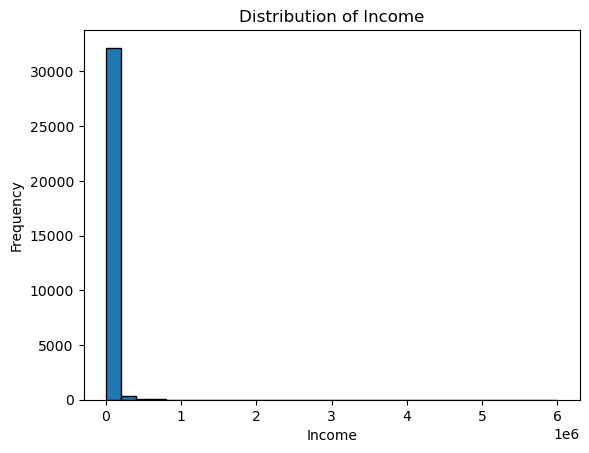

In [170]:
plt.hist(loan_data['person_income'], bins=30, edgecolor='black')
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

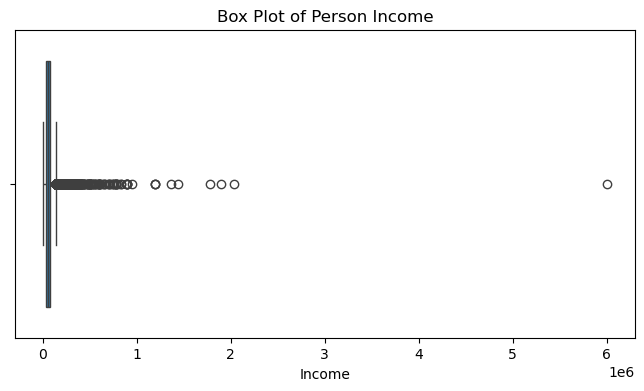

In [171]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=loan_data['person_income'])
plt.title('Box Plot of Person Income')
plt.xlabel('Income')
plt.show()

In [172]:
upper_limit = loan_data['person_income'].mean() + 3*loan_data['person_income'].std()
lower_limit = loan_data['person_income'].mean() - 3*loan_data['person_income'].std()
print(upper_limit)
print(lower_limit)

252024.20597444434
-119874.50903451005


In [173]:
loan_data.loc[(loan_data['person_income'] > upper_limit) | (loan_data['person_income'] < lower_limit)]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15,23,500000,MORTGAGE,7.0,DEBTCONSOLIDATION,B,30000,10.65,0,0.06,N,3
33,25,306000,RENT,2.0,DEBTCONSOLIDATION,C,24250,13.85,0,0.08,N,3
34,26,300000,MORTGAGE,10.0,MEDICAL,C,7800,13.49,0,0.03,N,4
42,26,300000,MORTGAGE,10.0,VENTURE,A,20000,7.88,0,0.07,N,4
43,23,300000,OWN,1.0,EDUCATION,F,24250,19.41,0,0.08,Y,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32497,63,1782000,RENT,13.0,EDUCATION,C,12025,14.27,0,0.01,N,30
32543,52,720000,MORTGAGE,1.0,PERSONAL,A,7925,8.94,0,0.01,N,30
32544,58,780000,MORTGAGE,7.0,PERSONAL,A,4500,6.91,0,0.01,N,20
32546,60,1900000,MORTGAGE,5.0,PERSONAL,A,1500,NaN,0,0.00,N,21


In [174]:
# Keep rows that are within the upper and lower limits
loan_data = loan_data[
    (loan_data['person_income'] <= upper_limit)
    & (loan_data['person_income'] >= lower_limit)
]

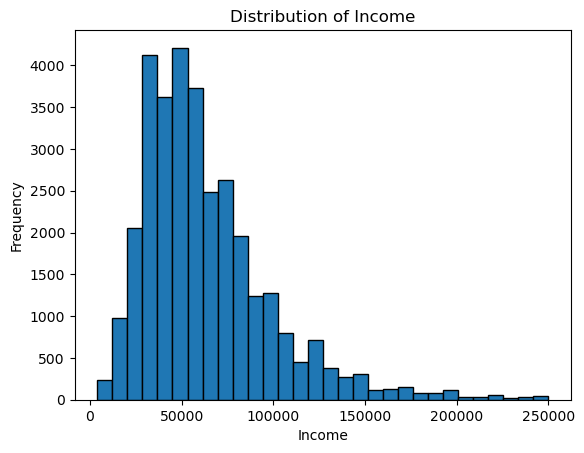

In [175]:
plt.hist(loan_data['person_income'], bins=30, edgecolor='black')
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

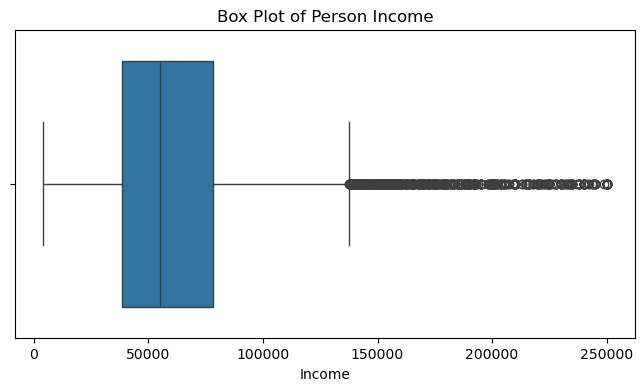

In [176]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=loan_data['person_income'])
plt.title('Box Plot of Person Income')
plt.xlabel('Income')
plt.show()

In [177]:
loan_data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32348.000000,32348.000000,31456.000000,32348.000000,29252.000000,32348.000000,32348.000000,32348.000000
mean,27.686967,63222.347749,4.774065,9530.460152,11.004228,0.218901,0.171062,5.776029
std,6.282752,35600.774119,4.130856,6254.381390,3.238669,0.413508,0.106646,4.031664
min,20.000000,4000.000000,0.000000,500.000000,5.420000,0.000000,0.010000,2.000000
25%,23.000000,38400.000000,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,55000.000000,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,78000.000000,7.000000,12000.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,250000.000000,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


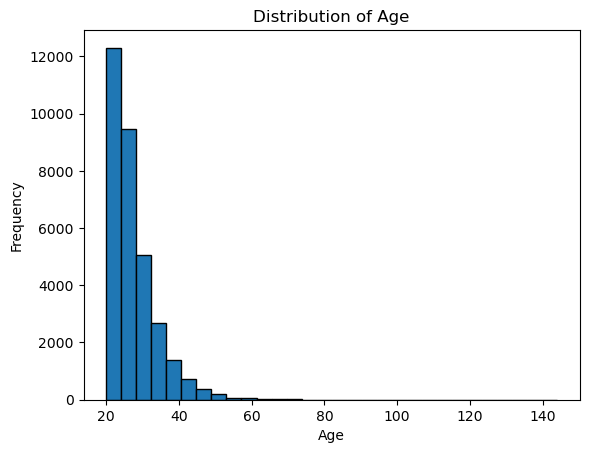

In [178]:
plt.hist(loan_data['person_age'], bins=30, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

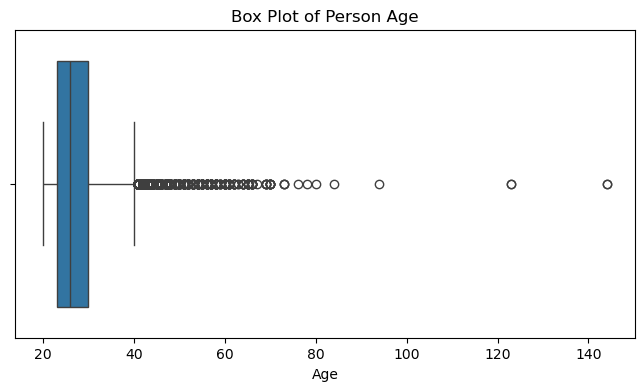

In [179]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=loan_data['person_age'])
plt.title('Box Plot of Person Age')
plt.xlabel('Age')
plt.show()

In [180]:
loan_data.loc[(loan_data['person_age'] > 80) | (loan_data['person_age'] < 18)]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32416,94,24000,RENT,1.0,MEDICAL,C,6500,NaN,0,0.27,N,27
32506,84,94800,MORTGAGE,2.0,PERSONAL,A,10000,7.51,0,0.11,N,24


In [181]:
loan_data.loc[loan_data['person_age']>80, 'person_age'] = 80
loan_data.loc[loan_data['person_age']<18, 'person_age'] = 18

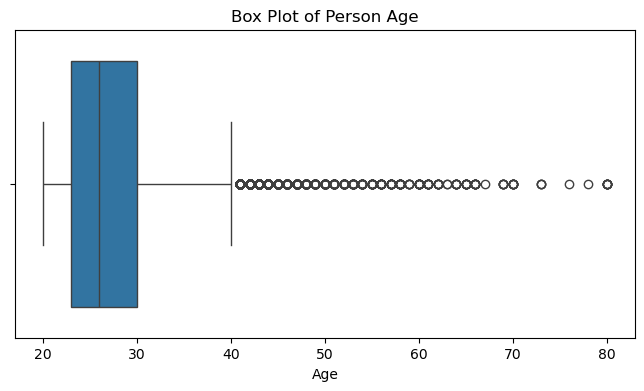

In [182]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=loan_data['person_age'])
plt.title('Box Plot of Person Age')
plt.xlabel('Age')
plt.show()

In [183]:
loan_data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32348.000000,32348.000000,31456.000000,32348.000000,29252.000000,32348.000000,32348.000000,32348.000000
mean,27.679795,63222.347749,4.774065,9530.460152,11.004228,0.218901,0.171062,5.776029
std,6.192608,35600.774119,4.130856,6254.381390,3.238669,0.413508,0.106646,4.031664
min,20.000000,4000.000000,0.000000,500.000000,5.420000,0.000000,0.010000,2.000000
25%,23.000000,38400.000000,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,55000.000000,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,78000.000000,7.000000,12000.000000,13.470000,0.000000,0.230000,8.000000
max,80.000000,250000.000000,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


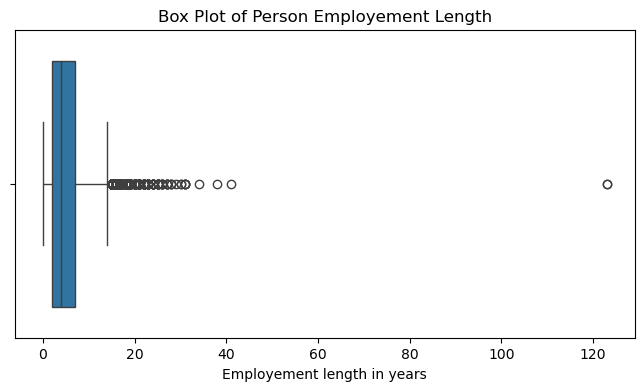

In [184]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=loan_data['person_emp_length'])
plt.title('Box Plot of Person Employement Length')
plt.xlabel('Employement length in years')
plt.show()

In [185]:
loan_data = loan_data.loc[(loan_data['person_emp_length']>=18) & (loan_data['person_emp_length']<=42)]

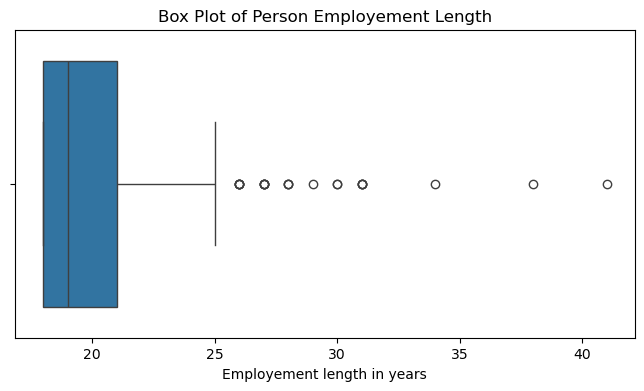

In [186]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=loan_data['person_emp_length'])
plt.title('Box Plot of Person Employement Length')
plt.xlabel('Employement length in years')
plt.show()

In [187]:
loan_data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,311.000000,311.000000,311.000000,311.000000,283.000000,311.000000,311.000000,311.000000
mean,39.765273,81304.369775,20.440514,11272.186495,11.079152,0.183280,0.157910,12.813505
std,6.670558,44519.211056,3.264990,7556.206467,3.479372,0.387519,0.106167,4.237004
min,33.000000,18720.000000,18.000000,1000.000000,5.420000,0.000000,0.010000,5.000000
25%,35.000000,49426.500000,18.000000,6000.000000,7.745000,0.000000,0.080000,10.000000
50%,38.000000,70000.000000,19.000000,9925.000000,10.990000,0.000000,0.130000,13.000000
75%,42.000000,98002.000000,21.000000,15000.000000,13.490000,0.000000,0.210000,15.000000
max,78.000000,250000.000000,41.000000,35000.000000,21.270000,1.000000,0.550000,30.000000


In [188]:
loan_data['loan_int_rate'] = loan_data['loan_int_rate'].fillna(loan_data['loan_int_rate'].mean())

In [189]:
loan_data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,39.765273,81304.369775,20.440514,11272.186495,11.079152,0.183280,0.157910,12.813505
std,6.670558,44519.211056,3.264990,7556.206467,3.318521,0.387519,0.106167,4.237004
min,33.000000,18720.000000,18.000000,1000.000000,5.420000,0.000000,0.010000,5.000000
25%,35.000000,49426.500000,18.000000,6000.000000,7.950000,0.000000,0.080000,10.000000
50%,38.000000,70000.000000,19.000000,9925.000000,11.079152,0.000000,0.130000,13.000000
75%,42.000000,98002.000000,21.000000,15000.000000,13.430000,0.000000,0.210000,15.000000
max,78.000000,250000.000000,41.000000,35000.000000,21.270000,1.000000,0.550000,30.000000


**EXPLORATORY DATA ANALYSIS (EDA)**

<Axes: xlabel='loan_status', ylabel='count'>

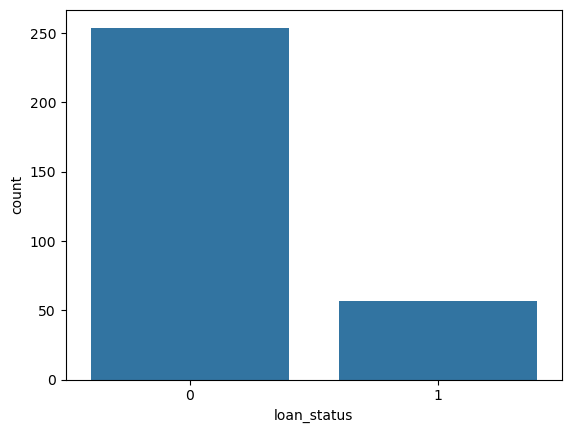

In [190]:
sns.countplot(x='loan_status', data=loan_data)

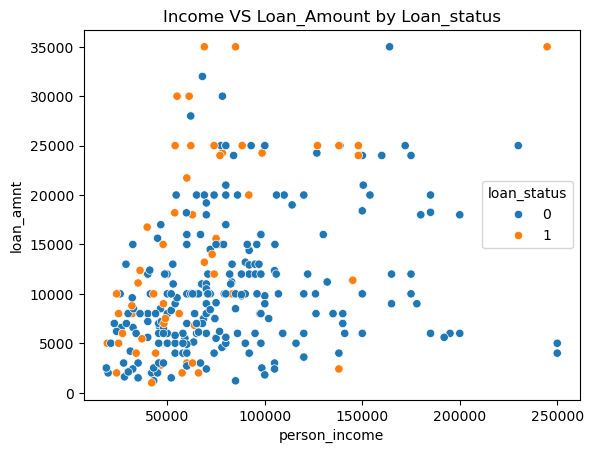

In [191]:
sns.scatterplot(x='person_income' , y='loan_amnt' , hue='loan_status' ,data = loan_data)
plt.title('Income VS Loan_Amount by Loan_status')
plt.show()

<B>Here we can observe that most of the loans are concentrated between low income ranges showing a strong correlation between income and loan amount</B><br>
<B>Also most of the loan defaults are observed in the lower oncome ranges only.</B>


<Axes: xlabel='loan_grade', ylabel='loan_status'>

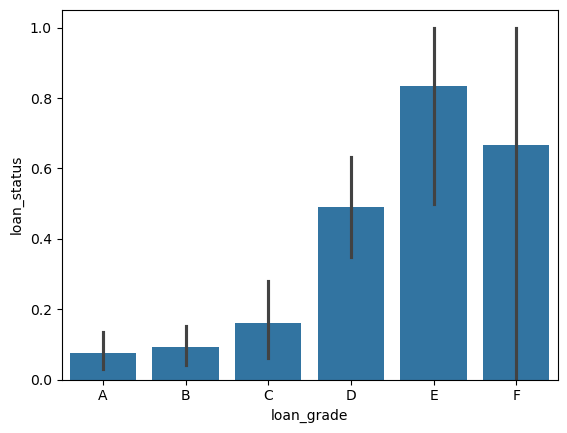

In [192]:
sns.barplot(x='loan_grade', y='loan_status', data=loan_data, order=['A','B','C','D','E','F'])

<Axes: xlabel='loan_status', ylabel='loan_percent_income'>

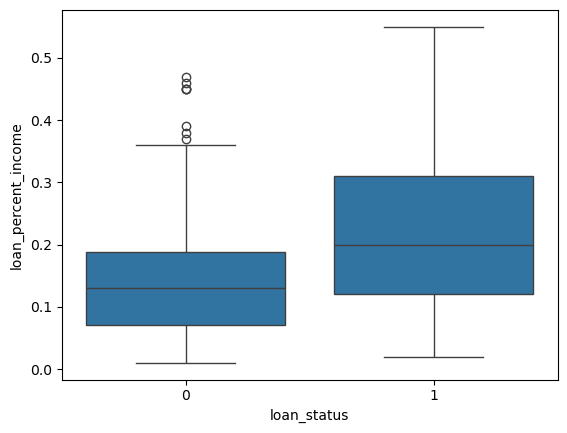

In [193]:
sns.boxplot(x='loan_status', y='loan_percent_income', data=loan_data)

<Axes: >

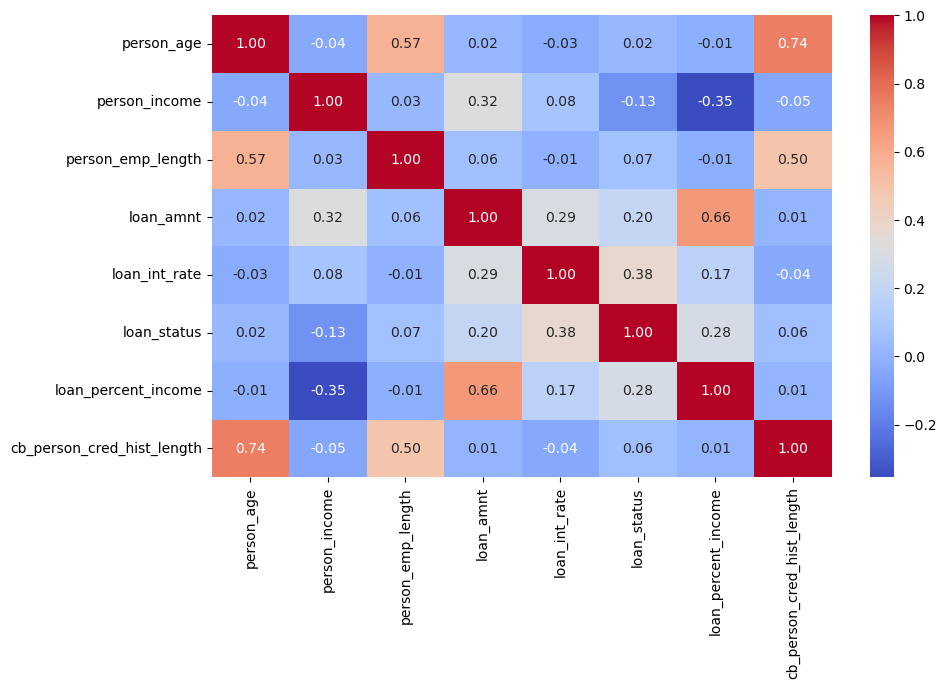

In [194]:
plt.figure(figsize=(10, 6))
sns.heatmap(loan_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

array([[<Axes: title={'center': 'person_income'}>,
        <Axes: title={'center': 'loan_amnt'}>],
       [<Axes: title={'center': 'person_age'}>, <Axes: >]], dtype=object)

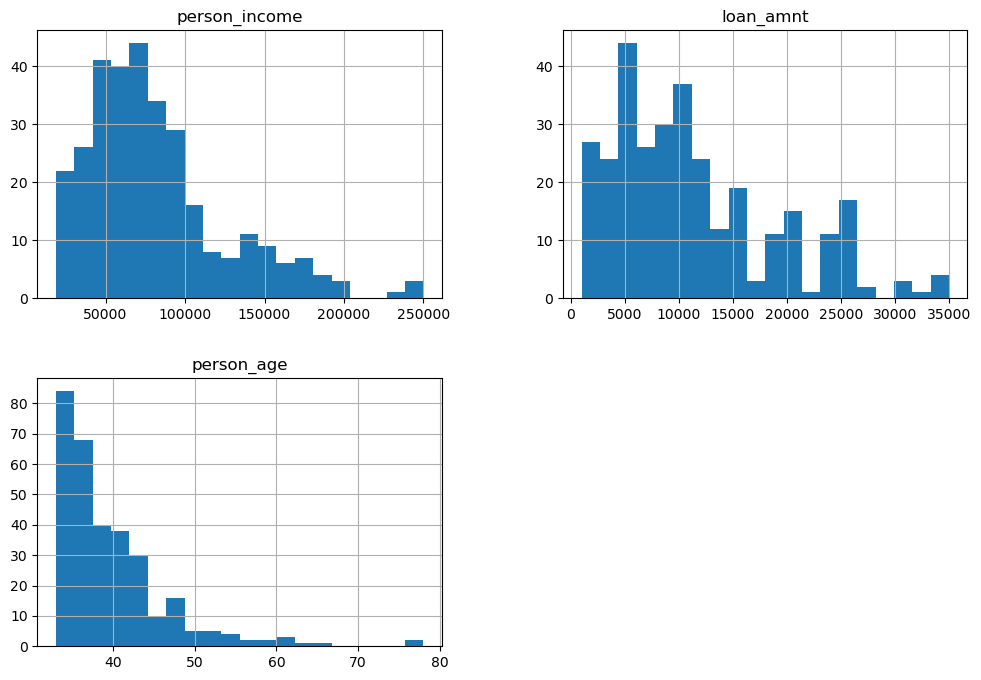

In [195]:
loan_data[['person_income', 'loan_amnt', 'person_age']].hist(bins=20, figsize=(12, 8))

In [196]:


# Create log-transformed versions of highly skewed columns
loan_data['person_income_log'] = np.log1p(loan_data['person_income'])
loan_data['loan_amnt_log'] = np.log1p(loan_data['loan_amnt'])


array([[<Axes: title={'center': 'person_income_log'}>,
        <Axes: title={'center': 'loan_amnt_log'}>],
       [<Axes: title={'center': 'person_age'}>, <Axes: >]], dtype=object)

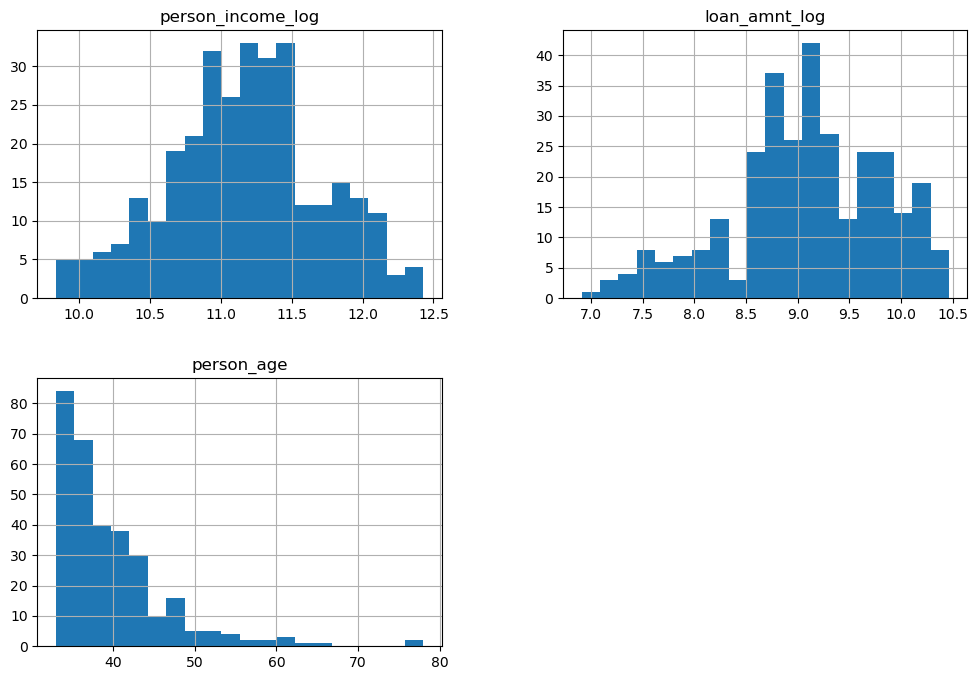

In [197]:
loan_data[['person_income_log', 'loan_amnt_log', 'person_age']].hist(bins=20, figsize=(12, 8))

In [198]:
X = loan_data.drop(columns=['loan_status', 'person_income', 'loan_amnt'])
y = loan_data['loan_status']

In [199]:
X = pd.get_dummies(X, drop_first=True)

**TRAIN-TEST-SPLIT**

In [200]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [201]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [202]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [203]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Predictions and probabilities
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.84      0.91        51
           1       0.58      0.92      0.71        12

    accuracy                           0.86        63
   macro avg       0.78      0.88      0.81        63
weighted avg       0.90      0.86      0.87        63

ROC-AUC Score: 0.9052


In [220]:
new_user = pd.DataFrame([{
    'person_age': 35,
    'person_income': 200000,
    'person_home_ownership': 'RENT',
    'person_emp_length': 19.0,
    'loan_intent': 'DEBTCONSOLIDATION',
    'loan_grade': 'C',
    'loan_amnt': 2000,
    'loan_int_rate': 10.68,
    'loan_percent_income': 0.02,
    'cb_person_default_on_file': 'Y',
    'cb_person_cred_hist_length': 3
}])

new_user_processed = new_user.copy()

# Apply log transformations
new_user_processed['person_income_log'] = np.log1p(new_user_processed['person_income'])
new_user_processed['loan_amnt_log'] = np.log1p(new_user_processed['loan_amnt'])

# Drop original raw columns
new_user_processed = new_user_processed.drop(columns=['person_income', 'loan_amnt'])

# One-hot encoding
new_user_processed = pd.get_dummies(new_user_processed)

# 3. REINDEX STRICTLY TO MATCH X_train COLUMNS EXACTLY
new_user_processed = new_user_processed.reindex(columns=X_train.columns, fill_value=0)

# 4. Scale using the fitted scaler
new_user_scaled = scaler.transform(new_user_processed)

# Print scaled array to verify values are reasonable (mostly between -3.0 and +3.0)
print("Scaled input features:\n", new_user_scaled)

# 5. Predict
prediction = model.predict(new_user_scaled)[0]
default_probability = model.predict_proba(new_user_scaled)[0][1]

print(f"\nLoan Decision: {'DEFAULT / HIGH RISK' if prediction == 1 else 'APPROVED / LOW RISK'}")
print(f"Default Probability: {default_probability:.2%}")


Scaled input features:
 [[-0.70823632 -0.45443385 -0.10852208 -1.29196899 -2.27666815  2.0284966
  -1.92408757 -0.06362848 -0.38490018  1.67791079 -0.33482477 -0.39859567
  -0.49621684 -0.39177592 -0.60219379 -0.69006556  2.21466971 -0.41875464
  -0.12803688 -0.09016696 -0.06362848  2.21466971]]

Loan Decision: APPROVED / LOW RISK
Default Probability: 40.38%
